<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 2 — Clasificación con k-NN y Naive Bayes</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Pima Indians Diabetes** (NIDDK, 1988), un clásico benchmark biomédico que contiene registros de **768 mujeres** con variables metabólicas y demográficas. La variable objetivo es `Outcome` (0 = no diabética, 1 = diabética con diabetes mellitus tipo 2).

Tu misión: construir, evaluar y comparar un clasificador **k-NN** y un **Naive Bayes Gaussiano** para predecir diabetes a partir de variables clínicas. Para cada decisión de diseño deberás **justificar clínicamente** tu elección.

---
> **Dataset:** `diabetes.csv`  
> **Fuente:** Smith, J.W. et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care.  
> Disponible en: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

---

### Variables del dataset

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Glucosa plasmática en ayunas (OGTT 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue tricipital | mm |
| Insulin | Insulina sérica a las 2h | μU/mL |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Score hereditario de diabetes | — |
| Age | Edad | años |
| **Outcome** | **Diagnóstico de diabetes** | **0/1** |

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — ¿k-NN o Naive Bayes? ¿O ambos?

Para este dataset de variables clínicas continuas, responde **antes de ver los datos**:

1. ¿Qué suposición hace Naive Bayes sobre las features? ¿Es razonable para glucosa, IMC y presión arterial? ¿Por qué?
2. k-NN requiere escalar los datos. Si no lo hicieras, ¿qué feature dominaría la distancia euclidiana y por qué? (pista: revisa las unidades de la tabla)
3. Para un sistema de tamizaje masivo (screening) de diabetes en una posta médica, ¿priorizarías **recall** o **precision**? Argumenta clínicamente.
4. Si la prevalencia de diabetes en la población fuera solo 5% (vs ~35% en este dataset), ¿cómo afectaría eso a la interpretación del posterior de Naive Bayes?

**📝 Tu respuesta (edita esta celda):**
1. Naive Bayes asume que las features son condicionalmente independientes dada la clase. Es decir, asume que variables como glucosa, IMC y presión arterial aportan información de forma separada. En la práctica, esta suposición no siempre es totalmente realista, porque algunas variables clínicas pueden estar relacionadas entre sí. Aun así, puede funcionar razonablemente bien como modelo simple y rápido.
2. Sí, k-NN requiere escalar los datos porque utiliza distancias, normalmente la distancia euclidiana. Si no se escalan, las variables con valores numéricos más grandes o con mayor rango dominarán la distancia. En este dataset, por ejemplo, Insulin o Glucose podrían influir más que otras variables como DiabetesPedigreeFunction, no necesariamente por ser más importantes clínicamente, sino por su escala numérica.
3. Para un sistema de tamizaje masivo de diabetes en una posta médica, priorizaría recall. Clínicamente, es más importante detectar la mayor cantidad posible de pacientes que realmente tienen diabetes, aunque eso implique algunos falsos positivos. Un falso negativo sería más grave, porque significaría dejar sin identificar a una persona enferma que necesita seguimiento o confirmación diagnóstica.
4. Si la prevalencia de diabetes en la población fuera solo 5%, eso afectaría directamente la interpretación posterior de Naive Bayes. Según el Teorema de Bayes, un prior más bajo para la clase positiva reduce la probabilidad posterior de clasificar a alguien como diabético, salvo que la evidencia observada sea muy fuerte. En consecuencia, el modelo tendería a predecir menos casos positivos, aumentando los falsos negativos y reduciendo el recall.

### 1.2 — Pipeline completo

Dibuja (en texto o diagrama) el pipeline que vas a implementar, indicando **en qué paso** se hace el train/test split y por qué es importante no cruzar esa frontera.

```
diabetes.csv
    │
    ▼
[ Paso A ] Carga de datos + limpieza inicial  ← ¿Qué haces aquí?
    │
    ▼
[ Paso B ] Separación X / y + train_test_split (estratificado)  ← ¿Aquí ya haces el split? ¿Por qué?
    │
    ├──────── TRAIN ──────────────────────────────────────────────┐
    │                                                             │
    ▼                                                             │
[ Paso C ] Imputación + escalado (fit SOLO con train)  ← ¿Qué estimas SOLO con train?        │
    │                                                             │
    ▼                                                             │
[ Paso D ] Entrenamiento de modelos (Naive Bayes, KNN)  ← Entrenamiento de modelos            │
    │                                                             │
    └──────── TEST ── (aplicas lo estimado en C) ─────────────────┘
    │
    ▼
[ Paso E ] (accuracy, recall, precision, F1, matrices de confusión)  ← Evaluación final
```

**📝 Tu respuesta (edita esta celda):** completa los `___` del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

In [2]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Colores UPCH
UPCH_RED  = '#8B0000'
UPCH_BLUE = '#1565C0'
UPCH_GRAY = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Ruta del dataset
DATA_PATH = Path('/content/drive/MyDrive/Colab Notebooks/Patrones/Clase3/diabetes.csv')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [4]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape: (768, 9)

Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Paso 2.2 — Distribución de clases y desbalance

Distribución de clases:
 No diabética (0): 500 pacientes (65.1%)
 Diabética    (1): 268 pacientes (34.9%)


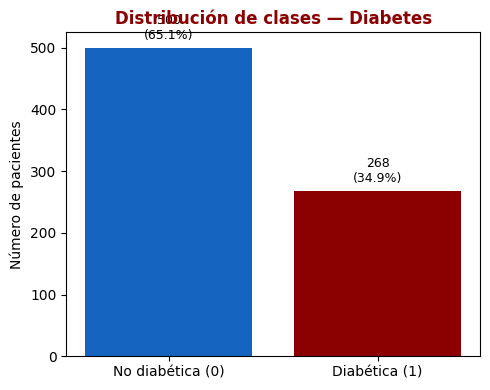

↪ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?
Si hay un desbalance, con la mayorìa de datos en lo normal. El dummy classifier daría un accuracy alto


In [7]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula el conteo y porcentaje de cada clase en 'Outcome'
conteo = df['Outcome'].value_counts()
pct    = df['Outcome'].value_counts(normalize=True) * 100

print('Distribución de clases:')
print(f" No diabética (0): {conteo[0]} pacientes ({pct[0]:.1f}%)")
print(f" Diabética    (1): {conteo[1]} pacientes ({pct[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))

# TODO 2: grafica las barras con colores [UPCH_BLUE, UPCH_RED]
barras = ax.bar([0, 1], [conteo[0], conteo[1]], color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabética (0)', 'Diabética (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico y porcentaje encima de cada barra
for i, barra in enumerate(barras):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 10,
        f'{int(altura)}\n({pct.iloc[i]:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('distribucion_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

print('↪ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?')
print('Si hay un desbalance, con la mayorìa de datos en lo normal. El dummy classifier daría un accuracy alto')

---
## Ejercicio 3 — Limpieza: valores fisiológicamente imposibles

Este dataset tiene un problema clásico: variables como Glucosa, BloodPressure, BMI e Insulin tienen valores **0** que son fisiológicamente imposibles. Son errores de adquisición codificados como 0 en lugar de `NaN`.

In [8]:
# Columnas que NO pueden ser 0 fisiológicamente
cols_no_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Valores = 0 por columna (antes de limpiar):')
for col in cols_no_cero:
    n_cero = (df[col] == 0).sum()
    print(f'  {col:<25} {n_cero:>4} ({100*n_cero/len(df):.1f}%)')

Valores = 0 por columna (antes de limpiar):
  Glucose                      5 (0.7%)
  BloodPressure               35 (4.6%)
  SkinThickness              227 (29.6%)
  Insulin                    374 (48.7%)
  BMI                         11 (1.4%)


In [9]:
df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores 0 por NaN en todas las columnas de cols_no_cero
# Pista: usa un loop o df_clean[cols_no_cero].replace()
___

print('Valores NaN tras limpieza:')
print(df_clean[cols_no_cero].isnull().sum())
print('\n→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.')

Valores NaN tras limpieza:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.


---
## Ejercicio 4 — EDA: ¿qué features separan mejor las clases?

Antes de entrenar cualquier modelo, exploramos visualmente qué variables tienen más **poder discriminativo**.

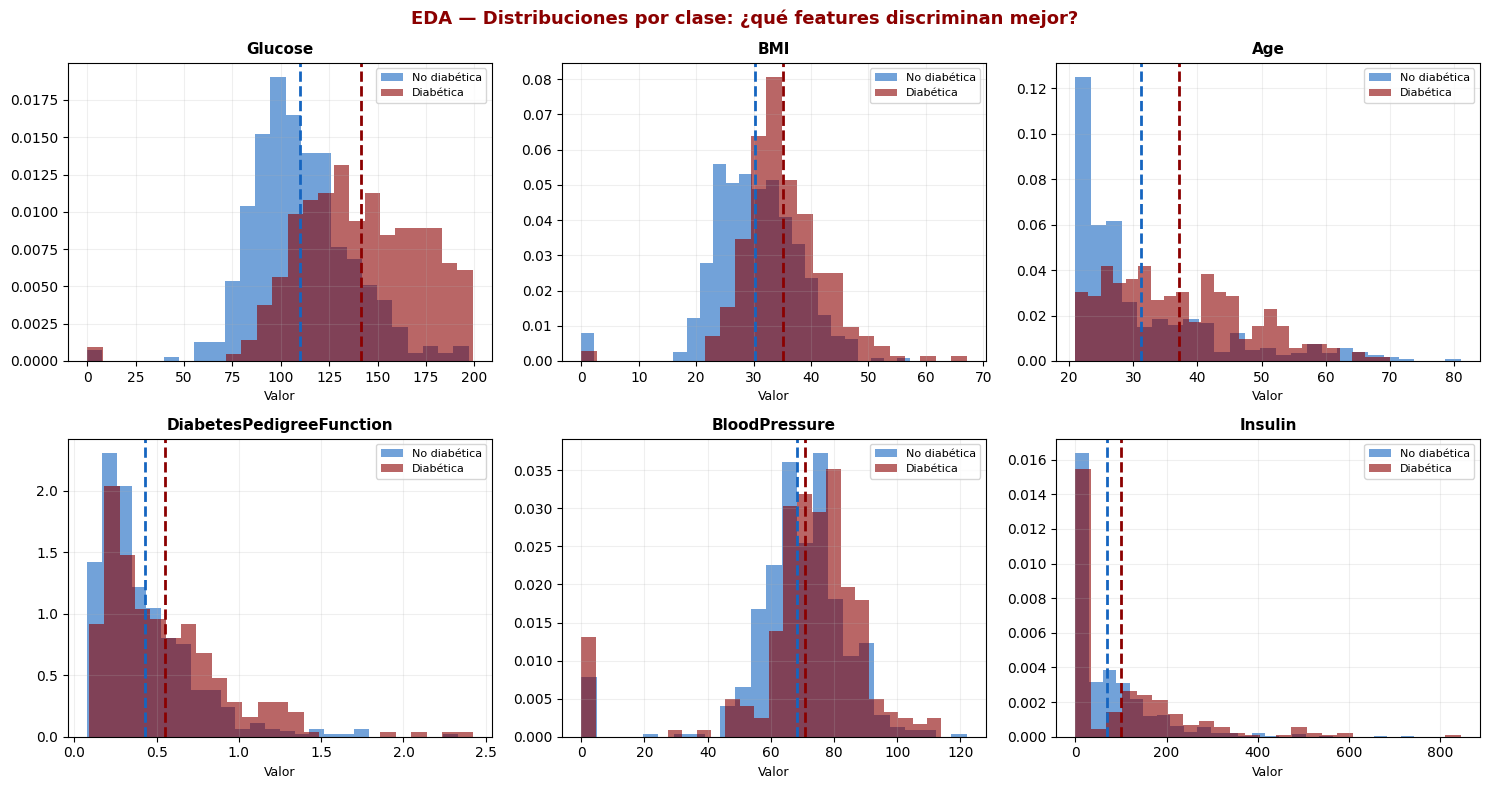

↪ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?
 El feature que tiene las distribuciones más separadas es la insulina, llegando a valores de 800. El que tiene más solapamiento es DiabetesPedigreeFunction


In [11]:
features_num = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]

    for clase, color, label in [(0, UPCH_BLUE, 'No diabética'), (1, UPCH_RED, 'Diabética')]:
        valores = df_clean[df_clean['Outcome'] == clase][feat].dropna()

        # Histograma superpuesto
        ax.hist(
            valores,
            bins=25,
            density=True,
            alpha=0.6,
            color=color,
            label=label
        )

        # Línea vertical de la media
        media = valores.mean()
        ax.axvline(
            media,
            color=color,
            linestyle='--',
            linewidth=2
        )

    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'EDA — Distribuciones por clase: ¿qué features discriminan mejor?',
    fontsize=13,
    fontweight='bold',
    color=UPCH_RED
)

plt.tight_layout()
plt.savefig('eda_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

print("↪ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?")
print(" El feature que tiene las distribuciones más separadas es la insulina, llegando a valores de 800. El que tiene más solapamiento es DiabetesPedigreeFunction")

### Paso 4.2 — Mapa de correlación

Naive Bayes asume independencia condicional. ¿Hay correlaciones fuertes entre features?

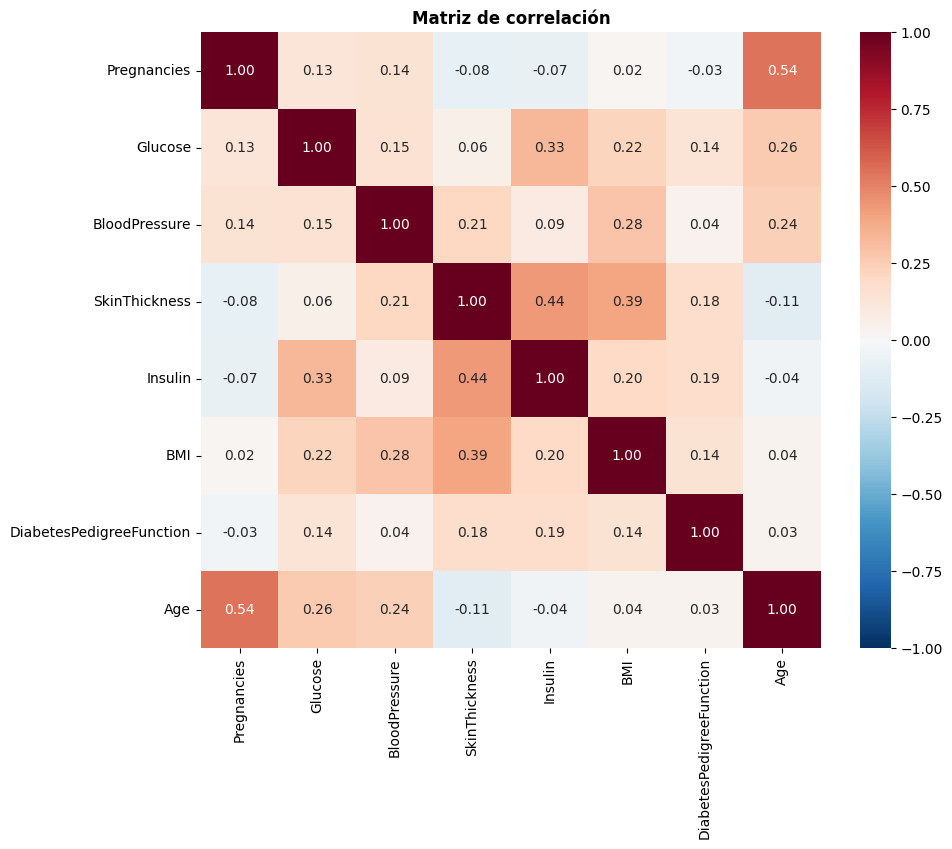

Pares con |correlación| > 0.5:

Pregnancies - Age: 0.54
No hay pares con correlaciones fuertes, el máximo es de 0.54 y no se considera fuerte


In [13]:
# Seleccionar solo variables numéricas (sin Outcome)
df_num = df_clean.drop(columns=['Outcome'])

# Matriz de correlación
corr = df_num.corr()

# Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title('Matriz de correlación', fontweight='bold')
plt.show()

# --- Identificar pares con correlación alta ---
print('Pares con |correlación| > 0.5:\n')

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) > 0.5:
            print(f"{corr.columns[i]} - {corr.columns[j]}: {valor:.2f}")
print('No hay pares con correlaciones fuertes, el máximo es de 0.54 y no se considera fuerte')

---
## Ejercicio 5 — Preprocesamiento: split, imputación y escalado

In [14]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: separa features (X) y target (y) de df_clean
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

# TODO 2: haz train_test_split con test_size=0.2, random_state=42, estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape}  →  {(y_train==1).sum()} diabéticas ({100*(y_train==1).mean():.1f}%)')
print(f'Test:  {X_test.shape}   →  {(y_test==1).sum()} diabéticas ({100*(y_test==1).mean():.1f}%)')

Train: (614, 8)  →  214 diabéticas (34.9%)
Test:  (154, 8)   →  54 diabéticas (35.1%)


In [15]:
# Calcular la mediana SOLO con train
mediana_train = X_train.median()

# Imputar NaN en train
X_train_imp = X_train.fillna(mediana_train)

# Imputar NaN en test usando la MISMA mediana de train
X_test_imp = X_test.fillna(mediana_train)

# Verificación
print(f'NaN en train tras imputación: {np.isnan(X_train_imp).sum().sum()}')
print(f'NaN en test tras imputación: {np.isnan(X_test_imp).sum().sum()}')

NaN en train tras imputación: 0
NaN en test tras imputación: 0


In [16]:
scaler = StandardScaler()

# Fit + transform SOLO en train
X_train_sc = scaler.fit_transform(X_train_imp)

# Solo transform en test
X_test_sc = scaler.transform(X_test_imp)

print(f'Train escalado — media: {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')

Train escalado — media: -0.0000  std: 1.0000


---
## Ejercicio 6 — Entrenamiento de modelos

### Paso 6.1 — Naive Bayes Gaussiano

In [18]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con X_train_imp (NB no necesita escalado, usa datos imputados)
gnb = GaussianNB()
gnb.fit(X_train_imp, y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb = gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7078


### Paso 6.2 — k-NN: selección de k óptimo

Entrena k-NN para **k = 1, 3, 5, 7, 9, 11, 15** usando validación interna sobre train (80/20). Grafica train vs val accuracy y selecciona k óptimo.

In [19]:
# --- COMPLETA EL CÓDIGO ---

# TODO 1: entrena un GaussianNB con X_train_imp
gnb = GaussianNB()
gnb.fit(X_train_imp, y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb = gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)

print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7078


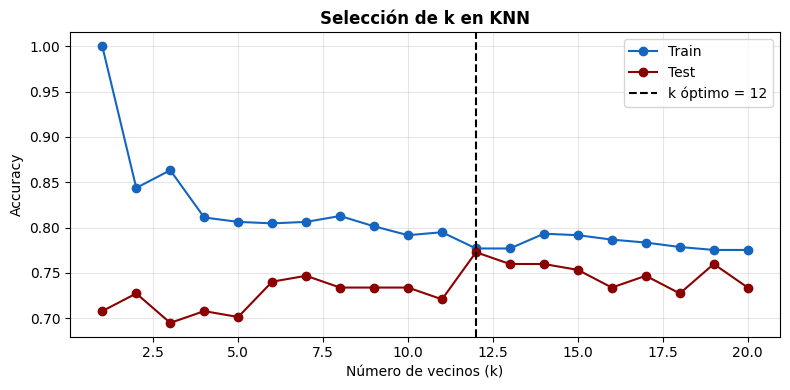

→ Mejor k según test: 12


In [20]:
# --- COMPLETA EL CÓDIGO ---

from sklearn.metrics import accuracy_score

k_values = range(1, 21)
train_acc = []
test_acc = []

# Calcular accuracy para cada k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Entrenar con datos ESCALADOS
    knn.fit(X_train_sc, y_train)

    # Predicciones
    y_train_pred = knn.predict(X_train_sc)
    y_test_pred = knn.predict(X_test_sc)

    # Guardar accuracy
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Mejor k (según test)
k_opt = k_values[np.argmax(test_acc)]

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, train_acc, marker='o', color=UPCH_BLUE, label='Train')
ax.plot(k_values, test_acc, marker='o', color=UPCH_RED, label='Test')

# Línea vertical en k óptimo
ax.axvline(k_opt, color='black', linestyle='--', label=f'k óptimo = {k_opt}')

ax.set_title('Selección de k en KNN', fontweight='bold')
ax.set_xlabel('Número de vecinos (k)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_seleccion_k_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'→ Mejor k según test: {k_opt}')

In [21]:
# --- COMPLETA EL CÓDIGO ---

# Entrenar KNN final con k óptimo
knn_opt = KNeighborsClassifier(n_neighbors=k_opt)
knn_opt.fit(X_train_sc, y_train)

# Predecir sobre test
y_pred_knn = knn_opt.predict(X_test_sc)

# Accuracy final
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f'K-NN (k={k_opt}) — Accuracy final en test: {acc_knn:.4f}')

K-NN (k=12) — Accuracy final en test: 0.7727


---
## Ejercicio 7 — Evaluación clínica

### Paso 7.1 — Matrices de confusión lado a lado

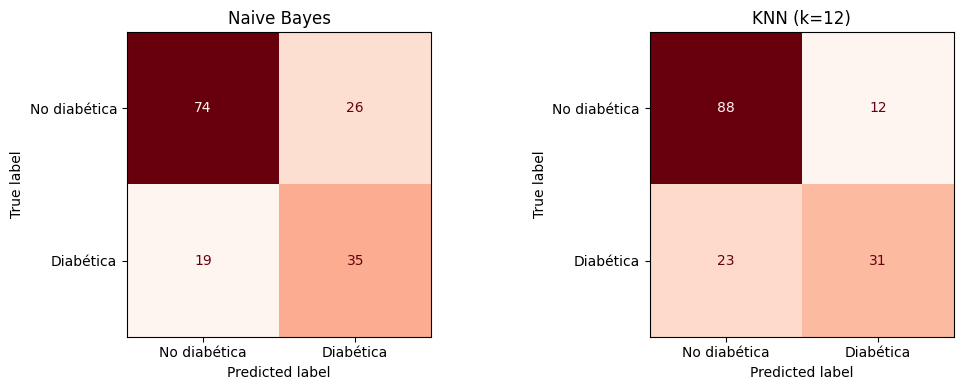

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Naive Bayes
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
disp_gnb = ConfusionMatrixDisplay(confusion_matrix=cm_gnb,
                                  display_labels=['No diabética', 'Diabética'])
disp_gnb.plot(ax=axes[0], cmap='Reds', colorbar=False)
axes[0].set_title('Naive Bayes')

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                  display_labels=['No diabética', 'Diabética'])
disp_knn.plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title(f'KNN (k={k_opt})')

plt.tight_layout()
plt.savefig('cm_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 7.2 — Tabla de métricas clínicas

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Naive Bayes
acc_gnb = accuracy_score(y_test, y_pred_gnb)
prec_gnb = precision_score(y_test, y_pred_gnb)
rec_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)

# KNN
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

# Tabla comparativa
tabla = pd.DataFrame({
    'Modelo': ['Naive Bayes', f'KNN (k={k_opt})'],
    'Accuracy': [acc_gnb, acc_knn],
    'Precision': [prec_gnb, prec_knn],
    'Recall': [rec_gnb, rec_knn],
    'F1-score': [f1_gnb, f1_knn]
})

tabla

,Modelo,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.707792,0.57377,0.648148,0.608696
1,KNN (k=12),0.772727,0.72093,0.574074,0.639175


### Paso 7.3 — Gráfico comparativo de métricas

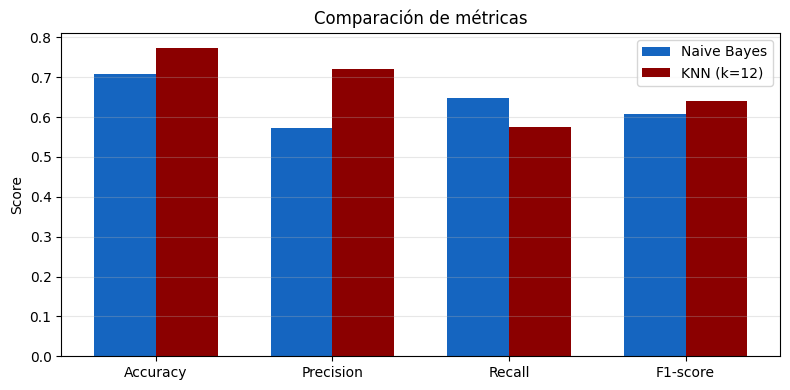

In [24]:
import numpy as np

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score']
gnb_vals = [acc_gnb, prec_gnb, rec_gnb, f1_gnb]
knn_vals = [acc_knn, prec_knn, rec_knn, f1_knn]

x = np.arange(len(metricas))
width = 0.35

plt.figure(figsize=(8,4))

plt.bar(x - width/2, gnb_vals, width, label='Naive Bayes', color=UPCH_BLUE)
plt.bar(x + width/2, knn_vals, width, label=f'KNN (k={k_opt})', color=UPCH_RED)

plt.xticks(x, metricas)
plt.ylabel('Score')
plt.title('Comparación de métricas')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 8 — Umbral de decisión y probabilidades posteriores

Naive Bayes entrega **probabilidades**, no solo etiquetas. En clínica podemos ajustar el umbral de decisión según el contexto:
- Tamizaje masivo → umbral bajo → maximizar recall (menos FN)
- Confirmación diagnóstica → umbral alto → maximizar precision (menos FP)

Por defecto, scikit-learn usa umbral = 0.5.

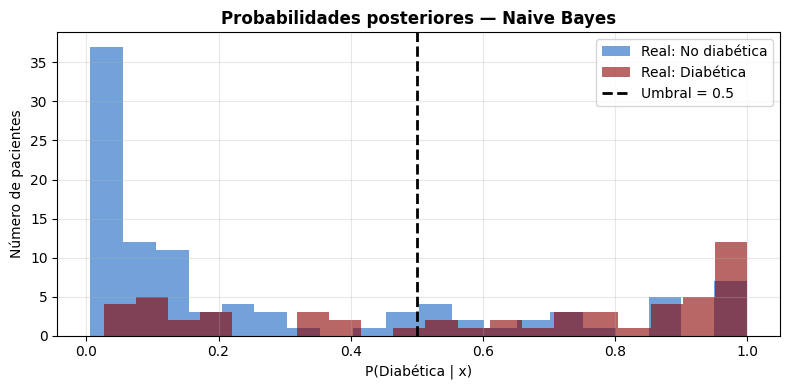

In [25]:
# Probabilidades posteriores de Naive Bayes
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]   # P(Diabética | x)

fig, ax = plt.subplots(figsize=(8, 4))

# Clase real 0
ax.hist(
    proba_gnb[y_test == 0],
    bins=20,
    alpha=0.6,
    color=UPCH_BLUE,
    label='Real: No diabética'
)

# Clase real 1
ax.hist(
    proba_gnb[y_test == 1],
    bins=20,
    alpha=0.6,
    color=UPCH_RED,
    label='Real: Diabética'
)

# Umbral por defecto
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Umbral = 0.5')

ax.set_title('Probabilidades posteriores — Naive Bayes', fontweight='bold')
ax.set_xlabel('P(Diabética | x)')
ax.set_ylabel('Número de pacientes')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histograma_proba.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# --- COMPLETA EL CÓDIGO ---
# TODO 2: evalúa el modelo con umbral = 0.35 (tamizaje) y umbral = 0.65 (confirmación)
#         Compara recall y precision con ambos casos vs umbral por defecto (0.5)
#         Imprime una tabla con: umbral, precision, recall, F1

resultados_umbral = []

for umbral in [0.35, 0.50, 0.65]:
    y_pred_umbral = (proba_gnb >= umbral).astype(int)

    precision = precision_score(y_test, y_pred_umbral)
    recall = recall_score(y_test, y_pred_umbral)
    f1 = f1_score(y_test, y_pred_umbral)

    resultados_umbral.append({
        'Umbral': umbral,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

tabla_umbrales = pd.DataFrame(resultados_umbral)
print(tabla_umbrales)

print()
print('↪ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,')
print('  qué umbral recomendarías y por qué?')
print(' Se prioriza la sensibilidad (Recall) ya que queremos evitar los falsos negativos')

   Umbral  Precision    Recall  F1-score
0    0.35   0.560606  0.685185  0.616667
1    0.50   0.573770  0.648148  0.608696
2    0.65   0.617021  0.537037  0.574257

↪ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,
  qué umbral recomendarías y por qué?
 Se prioriza la sensibilidad (Recall) ya que queremos evitar los falsos negativos


---
## Ejercicio 9 — Impacto del Prior (reflexión bayesiana)

El Teorema de Bayes que estudiamos en Clase 1 está en el corazón de Naive Bayes. Ahora lo aplicamos directamente.

In [28]:
# Naive Bayes con prior ajustado manualmente
# Simulamos que estamos en una población con baja prevalencia de diabetes (5%)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con priors=[0.95, 0.05]
#         (usar parámetro priors= en el constructor)

gnb_lowprev = GaussianNB(priors=[0.95, 0.05])
gnb_lowprev.fit(X_train_imp, y_train)

# TODO 2: predice y calcula recall, precision y accuracy en test
y_pred_lp = gnb_lowprev.predict(X_test_imp)

print('Comparación de priors:')
print(f'  Prior original (~35% diabetes):  Recall={recall_score(y_test, y_pred_gnb):.4f}  Precision={precision_score(y_test, y_pred_gnb):.4f}  Accuracy={accuracy_score(y_test, y_pred_gnb):.4f}')
print(f'  Prior 5% diabetes:              Recall={recall_score(y_test, y_pred_lp):.4f}  Precision={precision_score(y_test, y_pred_lp):.4f}  Accuracy={accuracy_score(y_test, y_pred_lp):.4f}')

print()
print('↪ Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?')
print('  Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).')
print("Cuando la prevalencia baja, el recall disminuye porque el modelo favorece la clase negativa. Esto se debe a que, según el Teorema de Bayes, un prior bajo reduce la probabilidad posterior de la clase positiva.")

Comparación de priors:
  Prior original (~35% diabetes):  Recall=0.6481  Precision=0.5738  Accuracy=0.7078
  Prior 5% diabetes:              Recall=0.3148  Precision=0.7083  Accuracy=0.7143

↪ Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?
  Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).
Cuando la prevalencia baja, el recall disminuye porque el modelo favorece la clase negativa. Esto se debe a que, según el Teorema de Bayes, un prior bajo reduce la probabilidad posterior de la clase positiva.


---
## Ejercicio 10 — Análisis final e interpretación clínica

Responde las siguientes preguntas integrando los resultados obtenidos:

### 10.1 — ¿Cuál modelo elegirías y para qué escenario?

Completa la tabla:

| Escenario | Modelo recomendado | Métrica prioritaria | Justificación |
|---|---|---|---|
| Screening masivo en posta rural | Naive Bayes (umbral bajo, ej. 0.35) | Recall | En tamizaje es fundamental detectar la mayor cantidad de pacientes posibles. Un mayor recall reduce los falsos negativos, evitando dejar casos sin diagnosticar, lo cual es crítico en contextos con acceso limitado a salud. |
| Confirmación diagnóstica en hospital | KNN (k=12) o NB con umbral alto (0.65) | Precision | En este escenario se busca minimizar falsos positivos para evitar diagnósticos incorrectos y tratamientos innecesarios. Una mayor precision asegura que los pacientes clasificados como positivos realmente lo sean. |
| Sistema embebido en glucómetro portátil | Naive Bayes | Velocidad / simplicidad | Naive Bayes es computacionalmente eficiente, requiere pocos recursos y es rápido, lo cual es ideal para dispositivos portátiles con capacidad limitada de procesamiento. |

**📝 Tu respuesta (edita esta celda)**

### 10.2 — Limitaciones del análisis

1. ¿Qué asunciones de Naive Bayes se violan en este dataset? ¿Cómo lo detectaste?
2. ¿Por qué k-NN puede ser problemático si el dataset tuviera 50,000 pacientes y 200 features?
3. ¿Qué otra métrica de evaluación sería importante reportar en el contexto clínico?

**📝 Tu respuesta (edita esta celda):**
1. Naive Bayes asume independencia entre las variables. En este dataset, se observa correlación entre algunas variables, como Pregnancies y Age (≈0.54), lo que viola parcialmente esta suposición. Esto se detectó mediante la matriz de correlación. Sin embargo, el impacto es moderado, ya que las correlaciones no son extremadamente altas.
2. KNN puede volverse muy costoso computacionalmente en datasets grandes, ya que necesita calcular distancias entre el nuevo punto y todos los datos de entrenamiento. Con 50,000 pacientes y 200 variables, el tiempo de predicción y el uso de memoria aumentan significativamente. Además, en alta dimensionalidad, las distancias pierden significado (curse of dimensionality), reduciendo la efectividad del modelo.
3. Una métrica importante adicional es la especificidad, que mide la capacidad de identificar correctamente a los pacientes sanos. También es relevante el AUC-ROC, que evalúa el desempeño del modelo a distintos umbrales. En contextos clínicos, combinar sensibilidad (recall) y especificidad permite una mejor evaluación del impacto del modelo.

In [29]:
# Resumen ejecutivo final
print('-' * 60)
print('              RESUMEN DEL CHALLENGE 2')
print('-' * 60)
print(f'Dataset: Pima Indians Diabetes  (N={len(df)}, d=8)')
print(f'Prevalencia en test: {100*(y_test==1).mean():.1f}%')
print()

print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1":<12}')
print('-' * 60)

for nombre, y_p in [(f'k-NN (k={k_opt})', y_pred_knn), ('Naive Bayes', y_pred_gnb)]:
    print(f'{nombre:<20} '
          f'{accuracy_score(y_test, y_p):.4f}        '
          f'{recall_score(y_test, y_p):.4f}       '
          f'{precision_score(y_test, y_p):.4f}        '
          f'{f1_score(y_test, y_p):.4f}')

print()
print('Archivos generados:')
print('  distribucion_diabetes.png   eda_diabetes.png')
print('  knn_seleccion_k_diabetes.png cm_comparacion.png')
print('  comparacion_metricas.png    histograma_proba.png')

------------------------------------------------------------
              RESUMEN DEL CHALLENGE 2
------------------------------------------------------------
Dataset: Pima Indians Diabetes  (N=768, d=8)
Prevalencia en test: 35.1%

Modelo               Accuracy     Recall       Precision    F1          
------------------------------------------------------------
k-NN (k=12)          0.7727        0.5741       0.7209        0.6392
Naive Bayes          0.7078        0.6481       0.5738        0.6087

Archivos generados:
  distribucion_diabetes.png   eda_diabetes.png
  knn_seleccion_k_diabetes.png cm_comparacion.png
  comparacion_metricas.png    histograma_proba.png
